<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/notebooks/colab/Day_4_CNN_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive, userdata
import os, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datetime import datetime

drive.mount('/content/drive')

try:
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    print("✓ HF Token set")
except:
    print("⚠ No HF Token")

BASE    = "/content/drive/MyDrive/rare_disease_project"
DATA    = f"{BASE}/data"
RESULTS = f"{BASE}/results"
MODELS  = f"{BASE}/models"

os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load splits
with open(f"{DATA}/splits/exp1_train.pkl", "rb") as f:
    exp1_train = pickle.load(f)
with open(f"{DATA}/splits/full_test.pkl", "rb") as f:
    full_test = pickle.load(f)
with open(f"{DATA}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print(f"✓ Setup complete")
print(f"  Device      : {torch.cuda.get_device_name(0)}")
print(f"  Train size  : {len(exp1_train)}")
print(f"  Test size   : {len(full_test)}")
print(f"  Num classes : {len(le.classes_)}")

Mounted at /content/drive
✓ HF Token set
✓ Setup complete
  Device      : Tesla T4
  Train size  : 514
  Test size   : 5339
  Num classes : 795


## **Image Dataset Class**

In [6]:
import os

# Verify paths directly — no parsing needed
print("Checking image paths directly...")
found    = 0
notfound = 0

for _, row in exp1_train.head(10).iterrows():
    images = row['images']  # already a list
    if images:
        path   = images[0]['path']
        exists = os.path.exists(path)
        print(f"  {'✓' if exists else '✗'} {path[-70:]}")
        if exists:
            found += 1
        else:
            notfound += 1

print(f"\nFound    : {found}")
print(f"Not found: {notfound}")

Checking image paths directly...
  ✓ ase_project/data/zebramap/images/1083/PMC9636884/PGPM-15-913-g0001.jpg
  ✓ ase_project/data/zebramap/images/1083/PMC3925134/1471-2350-15-15-1.jpg
  ✓ /data/zebramap/images/1083/PMC11786807/cureus-0017-00000076804-i01.jpg
  ✓ sease_project/data/zebramap/images/1083/PMC1079877/1471-2431-5-5-1.jpg
  ✓ ease_project/data/zebramap/images/1083/PMC3415795/ajmg0155-3035-f2.jpg
  ✓ e_project/data/zebramap/images/1083/PMC10655510/MGG3-11-e2254-g005.jpg
  ✓ ject/data/zebramap/images/1083/PMC5970537/13052_2018_500_Fig1_HTML.jpg
  ✓ e_project/data/zebramap/images/1083/PMC8150808/genes-12-00703-g001.jpg
  ✓ ata/zebramap/images/1083/PMC9880567/10.1177_23247096221150637-fig2.jpg
  ✓ ct/data/zebramap/images/1083/PMC10492392/12887_2023_4272_Fig1_HTML.jpg

Found    : 10
Not found: 0


In [7]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class ZebraMapImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.samples   = []
        self.transform = transform

        for _, row in df.iterrows():
            try:
                images = row['images']
                if not isinstance(images, list):
                    continue
                for img_info in images:
                    path = img_info['path']
                    if os.path.exists(path):
                        self.samples.append({
                            'path' : path,
                            'label': row['label']
                        })
                        break
            except:
                continue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            img = Image.open(sample['path']).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except:
            img = torch.zeros(3, 224, 224)

        return {
            'image': img,
            'label': torch.tensor(sample['label'], dtype=torch.long)
        }

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Remap labels
train_labels  = set(exp1_train['label'].unique())
sorted_labels = sorted(train_labels)
label_remap   = {old: new for new, old in enumerate(sorted_labels)}
reverse_remap = {new: old for old, new in label_remap.items()}

exp1_remapped = exp1_train.copy()
exp1_remapped['label'] = exp1_remapped['label'].map(label_remap)

test_filtered = full_test[full_test['label'].isin(train_labels)].reset_index(drop=True)
test_remapped = test_filtered.copy()
test_remapped['label'] = test_remapped['label'].map(label_remap)

print("Building datasets...")
train_dataset = ZebraMapImageDataset(exp1_remapped, train_transform)
test_dataset  = ZebraMapImageDataset(test_remapped,  test_transform)

print(f"  Train images : {len(train_dataset)}")
print(f"  Test images  : {len(test_dataset)}")

if len(train_dataset) > 0 and len(test_dataset) > 0:
    train_loader = DataLoader(train_dataset, batch_size=32,
                              shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_dataset,  batch_size=32,
                              shuffle=False, num_workers=2)
    print(f"✓ DataLoaders ready")
    print(f"  Train batches : {len(train_loader)}")
    print(f"  Test batches  : {len(test_loader)}")
    print(f"  Classes       : {len(sorted_labels)}")
else:
    print("✗ Still no images — paste output")

Building datasets...
  Train images : 514
  Test images  : 2942
✓ DataLoaders ready
  Train batches : 17
  Test batches  : 92
  Classes       : 49


# **Verify Sample Images**

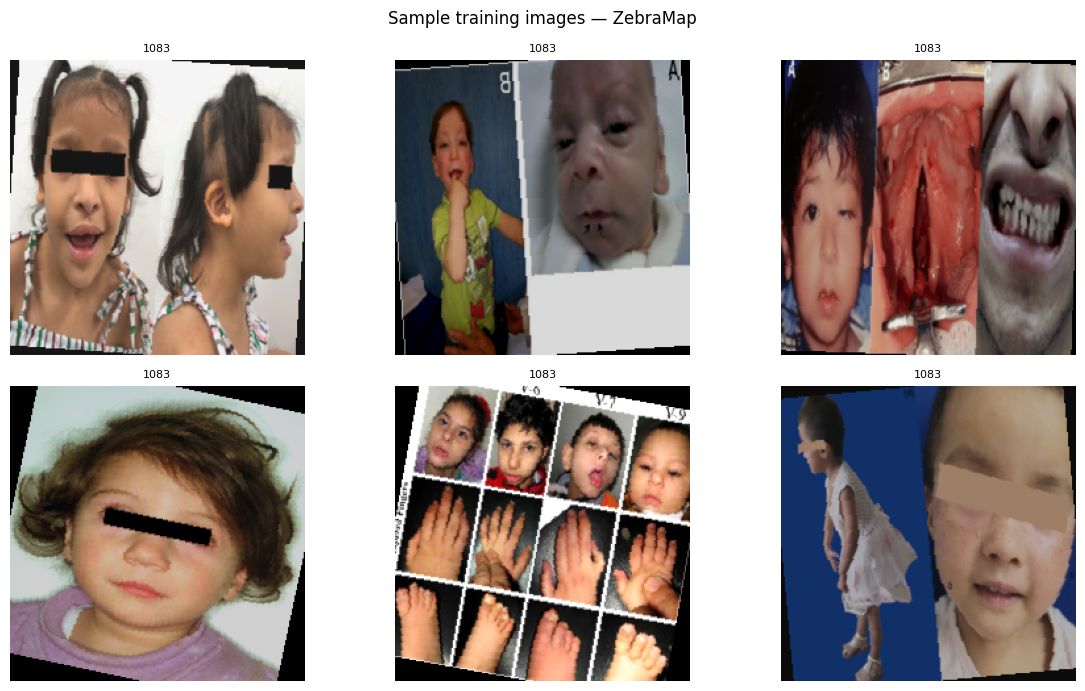

✓ Sample images verified


In [8]:
import matplotlib.pyplot as plt

# Show 6 sample images from training set
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

for i in range(6):
    sample = train_dataset[i]
    img    = sample['image']
    label  = sample['label'].item()

    # Denormalize
    img_show = img * std[:, None, None] + mean[:, None, None]
    img_show = img_show.permute(1, 2, 0).clamp(0, 1).numpy()

    # Get disease name
    orig_label   = reverse_remap[label]
    disease_name = le.inverse_transform([orig_label])[0]

    axes[i].imshow(img_show)
    axes[i].set_title(f"{disease_name[:25]}", fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample training images — ZebraMap', fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS}/day4_sample_images.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sample images verified")

# **ResNet-50 Model**

In [ ]:
import torchvision.models as models

class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze early layers — only train last 2 blocks + FC
        layers_to_freeze = list(backbone.children())[:-3]
        for layer in layers_to_freeze:
            for param in layer.parameters():
                param.requires_grad = False

        # Keep last 2 ResNet blocks trainable
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.features(x)
        return self.classifier(features)

num_classes = len(sorted_labels)
model_cnn   = ResNet50Classifier(num_classes=num_classes).to(device)

trainable = sum(p.numel() for p in model_cnn.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in model_cnn.parameters())

print(f"✓ ResNet-50 model built")
print(f"  Total params     : {total:,}")
print(f"  Trainable params : {trainable:,}")
print(f"  Frozen params    : {total - trainable:,}")
print(f"  Num classes      : {num_classes}")
print(f"  Device           : {device}")

# **Training Loop**

In [10]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS   = 15
LR       = 1e-4
BEST_ACC = 0.0

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_cnn.parameters()),
    lr=LR, weight_decay=0.01
)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

train_losses = []
train_accs   = []

print(f"Starting CNN training — {EPOCHS} epochs")
print("-" * 55)

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss    = 0
    correct       = 0
    total_samples = 0

    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model_cnn(images)
        loss   = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_cnn.parameters(), 1.0
        )

        optimizer.step()

        total_loss    += loss.item()
        preds          = logits.argmax(dim=1)
        correct       += (preds == labels).sum().item()
        total_samples += labels.size(0)

    scheduler.step()

    avg_loss = total_loss / len(train_loader)
    acc      = correct / total_samples * 100

    train_losses.append(avg_loss)
    train_accs.append(acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {acc:.2f}%")

print("-" * 55)
print("✓ Training complete")

Starting CNN training — 15 epochs
-------------------------------------------------------
Epoch 01/15 | Loss: 4.1581 | Train Acc: 1.95%
Epoch 02/15 | Loss: 3.8159 | Train Acc: 7.78%
Epoch 03/15 | Loss: 3.5641 | Train Acc: 11.28%
Epoch 04/15 | Loss: 3.3068 | Train Acc: 19.46%
Epoch 05/15 | Loss: 3.1106 | Train Acc: 28.21%
Epoch 06/15 | Loss: 2.8274 | Train Acc: 31.13%
Epoch 07/15 | Loss: 2.7308 | Train Acc: 37.35%
Epoch 08/15 | Loss: 2.5304 | Train Acc: 43.00%
Epoch 09/15 | Loss: 2.4024 | Train Acc: 47.08%
Epoch 10/15 | Loss: 2.2229 | Train Acc: 53.89%
Epoch 11/15 | Loss: 2.0810 | Train Acc: 59.73%
Epoch 12/15 | Loss: 2.0484 | Train Acc: 62.06%
Epoch 13/15 | Loss: 1.8669 | Train Acc: 66.73%
Epoch 14/15 | Loss: 1.8698 | Train Acc: 66.15%
Epoch 15/15 | Loss: 1.8676 | Train Acc: 64.59%
-------------------------------------------------------
✓ Training complete


# **Evaluation**

In [11]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_cnn_topk(model, loader, device, k=5):
    model.eval()
    all_preds    = []
    all_labels   = []
    top5_correct = 0
    total        = 0

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            logits = model(images)
            preds  = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            topk = logits.topk(k, dim=1).indices
            for i, lbl in enumerate(labels):
                if lbl in topk[i]:
                    top5_correct += 1
            total += labels.size(0)

    acc         = accuracy_score(all_labels, all_preds)
    f1_macro    = f1_score(all_labels, all_preds,
                           average='macro',    zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds,
                           average='weighted', zero_division=0)
    top5_acc    = top5_correct / total

    return {
        "accuracy"     : round(acc * 100, 2),
        "f1_macro"     : round(f1_macro * 100, 2),
        "f1_weighted"  : round(f1_weighted * 100, 2),
        "top5_accuracy": round(top5_acc * 100, 2),
        "total_samples": total
    }

print("Evaluating on test set...")
metrics_cnn = evaluate_cnn_topk(model_cnn, test_loader, device, k=5)

print("\n" + "=" * 55)
print("EXP 1 — CNN BASELINE RESULTS (5-10% scarcity)")
print("=" * 55)
print(f"  Accuracy     : {metrics_cnn['accuracy']}%")
print(f"  F1 Macro     : {metrics_cnn['f1_macro']}%")
print(f"  F1 Weighted  : {metrics_cnn['f1_weighted']}%")
print(f"  Top-5 Acc    : {metrics_cnn['top5_accuracy']}%")
print(f"  Test samples : {metrics_cnn['total_samples']}")

Evaluating on test set...

EXP 1 — CNN BASELINE RESULTS (5-10% scarcity)
  Accuracy     : 14.34%
  F1 Macro     : 5.0%
  F1 Weighted  : 19.31%
  Top-5 Acc    : 30.63%
  Test samples : 2942


# **Plot Training Curves**

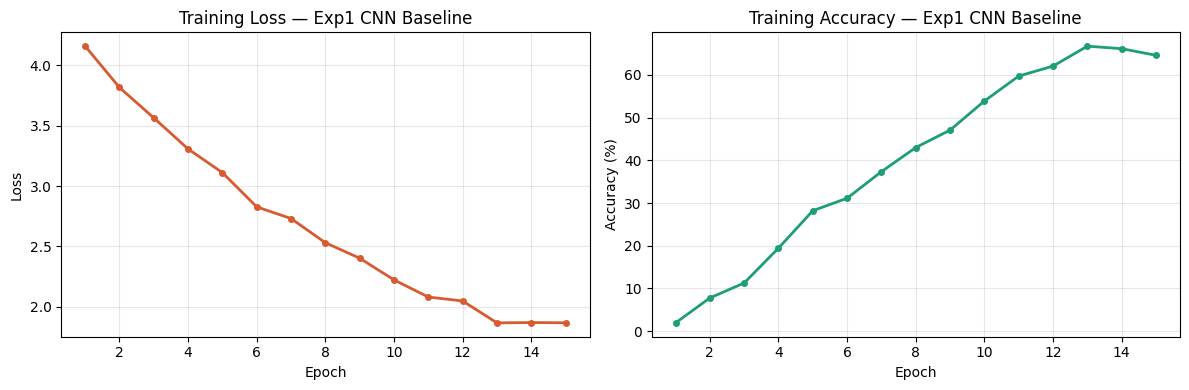

✓ Training curves saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses,
             color='#D85A30', linewidth=2,
             marker='o', markersize=4)
axes[0].set_title('Training Loss — Exp1 CNN Baseline')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), train_accs,
             color='#1D9E75', linewidth=2,
             marker='o', markersize=4)
axes[1].set_title('Training Accuracy — Exp1 CNN Baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS}/day4_cnn_baseline_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved")

# **Save Model + Results**

In [13]:
# Save model
cnn_model_path = f"{MODELS}/exp1_cnn_resnet50.pt"
torch.save({
    'model_state_dict': model_cnn.state_dict(),
    'label_remap'     : label_remap,
    'reverse_remap'   : reverse_remap,
    'num_classes'     : num_classes,
    'train_labels'    : sorted_labels,
    'metrics'         : metrics_cnn
}, cnn_model_path)
print(f"✓ CNN model saved → {cnn_model_path}")

# Update experiment tracker
tracker_path = f"{RESULTS}/experiment_tracker.json"
with open(tracker_path, "r") as f:
    tracker = json.load(f)

tracker['experiments']['exp1_baseline_scarcity']['cnn_metrics'] = metrics_cnn
tracker['last_updated'] = str(datetime.now().date())

with open(tracker_path, "w") as f:
    json.dump(tracker, f, indent=2)

print("✓ Tracker updated")

# Day 4 summary
summary = {
    "day"        : 4,
    "experiment" : "exp1_cnn_baseline",
    "model"      : "ResNet-50 pretrained ImageNet",
    "train_size" : len(train_dataset),
    "test_size"  : len(test_dataset),
    "epochs"     : EPOCHS,
    "classes"    : num_classes,
    "metrics"    : metrics_cnn,
    "status"     : "Day 4 complete"
}

with open(f"{RESULTS}/day4_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 55)
print("DAY 4 COMPLETE ✓")
print("=" * 55)
print(f"  Model        : ResNet-50")
print(f"  Train images : {len(train_dataset)}")
print(f"  Classes      : {num_classes}")
print(f"  Accuracy     : {metrics_cnn['accuracy']}%")
print(f"  F1 Macro     : {metrics_cnn['f1_macro']}%")
print(f"  Top-5 Acc    : {metrics_cnn['top5_accuracy']}%")
print(f"\n  Next → Day 5: Full dataset upper bound (Exp 3)")

✓ CNN model saved → /content/drive/MyDrive/rare_disease_project/models/exp1_cnn_resnet50.pt
✓ Tracker updated

DAY 4 COMPLETE ✓
  Model        : ResNet-50
  Train images : 514
  Classes      : 49
  Accuracy     : 14.34%
  F1 Macro     : 5.0%
  Top-5 Acc    : 30.63%

  Next → Day 5: Full dataset upper bound (Exp 3)
